# 神经网络（Neural Network）

神经网络是一种机器学习模型，它通过学习最优参数来逼近复杂函数。

GitHub 仓库：https://github.com/gavinkhung/neural-network

导入所需的库

In [1]:
import numpy as np

%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

## 训练数据集（Training Dataset）

神经网络将学习拟合双曲抛物面（Hyperbolic Paraboloid）的参数。

$
\begin{align*}
z &= \frac{y^2}{b^2} - \frac{x^2}{a^2}
\end{align*}
$

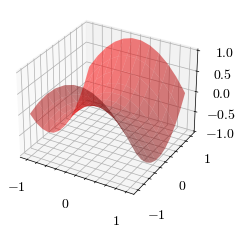

In [2]:
def generate_function(dims):
    a = 1
    b = 1

    # 双曲抛物面
    x = np.linspace(-1, 1, dims)
    y = np.linspace(-1, 1, dims)
    X, Y = np.meshgrid(x, y)
    Z = (Y**2 / b**2) - (X**2 / a**2)

    X_t = X.flatten()
    Y_t = Y.flatten()
    Z_t = Z.flatten()
    X_t = X_t.reshape((len(X_t), 1))
    Y_t = Y_t.reshape((len(Y_t), 1))
    Z_t = Z_t.reshape((len(Z_t), 1))
    features = np.stack((X_t, Y_t), axis=1)
    labels = Z_t.reshape((len(Z_t), 1, 1))

    return X, Y, Z, features, labels


dims = 12
X, Y, Z, features, labels = generate_function(dims)

# 可视化双曲抛物面
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, color="red", alpha=0.5)

## 损失函数（Loss Function）
损失函数用于评估模型的表现，并据此更新权重。神经网络训练的优化过程会寻找使损失最小化的权重和偏置（Bias）。

(mean-squared-error)=
### 均方误差（Mean Squared Error）
像均方误差这样的二次型损失函数用于回归任务，本例就属于回归任务。

$ J = \frac{1}{n} \sum_{i=1}^{n}(y_{i}-\hat{y})^2 $

In [3]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

(mean-squared-error-gradient)=
### 均方误差的梯度
为了执行反向传播（Backpropagation）来更新权重，我们需要计算损失函数的梯度（Gradient）。

$
\begin{align*}
J^{\prime} &= \frac{\partial}{\partial \hat{y}} [ \frac{1}{n} \sum_{i=1}^{n}(y_{i}-\hat{y})^2 ] \\
&= \frac{1}{n} \sum_{i=1}^{n}\frac{\partial}{\partial \hat{y}} [ (y_{i}-\hat{y})^2 ] \\
&= \frac{2}{n} \sum_{i=1}^{n} (y_{i}-\hat{y}) \frac{\partial}{\partial \hat{y}}[y_{i}-\hat{y}] \\
&= \frac{2}{n} \sum_{i=1}^{n} (y_{i}-\hat{y}) (-1) \\
&= \frac{2}{n} \sum_{i=1}^{n}(\hat{y}-y_{i})
\end{align*}
$

In [4]:
def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

## 神经网络层（Neural Network Layer）

我们将实现一个前馈神经网络（Feedforward Neural Network），它由许多层组成。从宏观上看，每一层对输入数据施加一个线性变换（Linear Transformation）来生成输出数据，输出数据的维度通常与输入数据不同。然后，输出中的所有值都会经过一个函数，这个函数称为激活函数（Activation Function）。

回顾线性代数（Linear Algebra）的知识，输入列向量 $x$ 属于 $\mathbb{R}^n$，它可以被变换到另一个维度 $\mathbb{R}^m$，变换的方法是与一个大小为 $m \times n$ 的矩阵相乘。最后，我们可以为这个线性变换加上一个偏置项（Bias Term），使变换后的数据整体上移或下移。

因此，每一层都会存储一个权重矩阵（Weight Matrix）和一个偏置向量（Bias Vector），用来执行这个线性变换。

In [5]:
from abc import ABC, abstractmethod


class Layer(ABC):
    def __init__(self):
        self.input = None
        self.output = None
        self.weights = None
        self.bias = None

    @abstractmethod
    def forward(self, input):
        pass

    @abstractmethod
    def backward(self, output_gradient, optimizer):
        pass

## 前向传播（Forward Propagation）

这是将输入数据转换为前馈神经网络预测结果的过程。输入数据会依次通过网络的每一层。下面是我们将要实现的 3 层网络的可视化。

![Neural Network](plot/nn.svg)

一层中的每个神经元都是其输入的加权和，再加上一个偏置项。最后，会对该层中的每个神经元应用一个激活函数。我们将用一个类来表示全连接层（Fully-Connected Layer），再用另一个类来表示激活函数。

每个神经元的计算——即输入与该层权重的乘积之和再加上一个偏置项——等价于权重矩阵与输入数据做矩阵乘法，然后加上一个偏置向量。

因此，全连接层的前向传播可以写成：

$
\begin{align*}
Z &= W X + B \\
A &= g(Z)
\end{align*}
$

其中：
- $W$ 是该层的权重矩阵
- $X$ 是输入数据
- $B$ 是偏置向量
- $g$ 是激活函数

(our-network-s-forward-propagation)=
## 我们的网络的前向传播

我们将实现一个 3 层全连接神经网络，每一层之后都接一个 Tanh 激活函数。这些变换可以写成如下的矩阵乘法：

$
\begin{align*}
Z_1 &= W_1 X + B_1 \\
A_1 &= tanh(Z_1) \\
\\
Z_2 &= W_2 A_1 + B_2 \\
A_2 &= tanh(Z_2) \\
\\
Z_3 &= W_3 A_2 + B_3 \\
\hat{y} &= A_3 = tanh(Z_3)
\end{align*}
$

## 反向传播

反向传播是利用链式法则（Chain Rule）和梯度下降（Gradient Descent）来更新神经网络中所有权重和偏置的过程。

下面的公式以 $J$ 作为我们的损失函数。在本 Notebook 中，我们使用均方误差损失函数。点击[这里查看均方误差损失函数](#mean-squared-error)。

我们的目标是利用以下公式对权重和偏置执行梯度下降：

$
\begin{align*}
W_1 &= W_1 - lr * \frac{\partial J}{\partial W_1} \\
B_1 &= B_1 - lr * \frac{\partial J}{\partial B_1} \\
W_2 &= W_2 - lr * \frac{\partial J}{\partial W_2} \\
B_2 &= B_2 - lr * \frac{\partial J}{\partial B_2} \\
W_3 &= W_3 - lr * \frac{\partial J}{\partial W_3} \\
B_3 &= B_3 - lr * \frac{\partial J}{\partial B_3} \\
\end{align*}
$

我们需要用链式法则求出 $\frac{\partial J}{\partial W_1}$、$\frac{\partial J}{\partial B_1}$、$\frac{\partial J}{\partial W_2}$、$\frac{\partial J}{\partial B_2}$、$\frac{\partial J}{\partial W_3}$ 和 $\frac{\partial J}{\partial B_3}$ 的值。

### 反向传播的链式法则

让我们推导一个通用公式，用来更新单个全连接层的权重矩阵 $W_i$ 和偏置向量 $B_i$。

例如，要对第 3 层应用梯度下降，我们需要求损失关于 $W_3$ 和 $B_3$ 的偏导，即 $\frac{\partial J}{\partial W_3}$ 和 $\frac{\partial J}{\partial B_3}$。

损失函数 $J$ 是 $A_3$ 的函数，即最后一层的最终输出/激活值。接着，$A_3$ 是 $Z_3$ 的函数。最后，$Z_3$ 是 $W_3$、$B_3$ 和 $A_2$（倒数第二层的激活值）的函数。下面来求损失关于 $W_3$ 和 $B_3$ 的偏导。

我们可以把这些矩阵运算表示成如下的复合函数：$J(A_3)$、$A_3(Z_3)$ 和 $Z_3(W_3, B_3, A_2)$

点击[这里查看每一层的运算](#our-network-s-forward-propagation)。

### 权重矩阵 W 的链式法则

用链式法则推导 $\frac{\partial J}{\partial W_3}$

$
\begin{align*}
\frac{\partial J}{\partial W_3} &= \frac{\partial}{\partial W_3}[J(A_3(Z_3(W_3, B_3, A_2)))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial}{\partial W_3}[A_3(Z_3(W_3, B_3, A_2))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial Z_3} \frac{\partial}{\partial W_3}[Z_3(W_3, B_3, A_2))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial Z_3} \frac{\partial Z_3}{\partial W_3} \\
\end{align*}
$

### 偏置向量 B 的链式法则

用链式法则推导 $\frac{\partial J}{\partial B_3}$。

$
\begin{align*}
\frac{\partial J}{\partial B_3} &= \frac{\partial}{\partial B_3}[J(A_3(Z_3(W_3, B_3, A_2)))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial}{\partial B_3}[A_3(Z_3(W_3, B_3, A_2))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial B_3} \frac{\partial}{\partial B_3}[Z_3(W_3, B_3, A_2))] \\
&= \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial Z_3} \frac{\partial Z_3}{\partial B_3} \\
\end{align*}
$

## 权重矩阵 W 的反向传播

$
\begin{align*}
\frac{\partial J}{\partial W_3} = \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial Z_3} \frac{\partial Z_3}{\partial W_3}
\end{align*}
$

让我们把每个部分拆开来看：

1. $\frac{\partial J}{\partial A_3}$ 是损失函数的梯度，也就是均方误差函数的梯度。点击[这里查看损失函数梯度的推导](#mean-squared-error-gradient)。对于任意一层的一般情况，这是来自下一层（idx+1）的梯度。

2. $\frac{\partial A_3}{\partial Z_3} = \frac{\partial}{\partial Z_3}[tanh(Z_3)] $ 是激活函数的梯度。点击[这里查看激活函数梯度的推导](#tanh-activation-function-gradient)。

3. $\frac{\partial Z_3}{\partial W_3} = \frac{\partial}{\partial W_3}[W_3 A_2 + B_3] = A_2$ 是该层的原始输入，也就是上一层（idx-1）的输出。

因此，全连接层权重矩阵的梯度是以下三者的矩阵乘积：
1. 来自下一层（idx+1）的梯度
2. 激活函数的梯度
3. 来自上一层（idx-1）的输入

## 偏置向量 B 的反向传播

$
\begin{align*}
\frac{\partial J}{\partial B_3} = \frac{\partial J}{\partial A_3} \frac{\partial A_3}{\partial Z_3} \frac{\partial Z_3}{\partial B_3}
\end{align*}
$

让我们把每个部分拆开来看： 

1. $\frac{\partial J}{\partial A_3}$ 是损失函数的梯度，也就是均方误差函数的梯度。点击[这里查看损失函数梯度的推导](#mean-squared-error-gradient)。对于任意一层的一般情况，这是来自下一层（idx+1）的梯度。

2. $\frac{\partial A_3}{\partial Z_3}$ 是激活函数的梯度。点击[这里查看激活函数梯度的推导](#tanh-activation-function-gradient)。

3. $\frac{\partial Z_3}{\partial B_3} = \frac{\partial}{\partial B_3}[W_3 A_2 + B_3] = 1$ 等于 1，在梯度计算中可以忽略它。

因此，全连接层偏置向量的梯度是以下两者的矩阵乘积：
1. 来自下一层（idx+1）的梯度
2. 激活函数的梯度

想了解更多，我推荐以下资源：
- [从零实现神经网络（Neural Network from Scratch）](https://www.youtube.com/watch?v=pauPCy_s0Ok)。我也观看了这个视频来帮助编写本 Notebook。
- [机器学习中最重要的算法（The Most Important Algorithm in Machine Learning）](https://www.youtube.com/watch?v=SmZmBKc7Lrs)

## 稠密层（Dense Layer）

稠密层就是全连接层。让我们利用上面前向传播和反向传播章节中推导出的公式，来实现稠密层类的 `forward()` 和 `backward()` 方法。

In [6]:
class Dense(Layer):
    def __init__(self, input_neurons, output_neurons):
        # 来自正态分布的随机值
        # self.weights = np.random.randn(output_neurons, input_neurons)
        # self.bias = np.random.randn(output_neurons, 1)

        # 全部为零
        # self.weights = np.zeros((output_neurons, input_neurons))
        # self.bias = np.zeros((output_neurons, 1))

        # Xavier 初始化的均匀分布
        limit = np.sqrt(6 / (input_neurons + output_neurons))
        self.weights = np.random.uniform(
            -limit, limit, size=(output_neurons, input_neurons)
        )
        self.bias = np.zeros((output_neurons, 1))

    def forward(self, input):
        self.input = input
        return np.matmul(self.weights, self.input) + self.bias

    def backward(self, output_gradient, optimizer):
        # 计算梯度
        weights_gradient = np.matmul(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        # 更新权重和偏置
        self.weights, self.bias = optimizer.backward(
            self.weights, weights_gradient, self.bias, output_gradient
        )
        return input_gradient

## 激活函数

激活函数在矩阵乘法之后应用，用来为神经网络引入非线性（Nonlinearity）。选择正确的激活函数，对神经网络能否学到训练数据的普遍模式至关重要。最值得一提的是，ReLU 函数在训练层数很多的深层神经网络时非常有用（正如 2012 年的 AlexNet 论文所示），它可以防止梯度消失（Vanishing Gradients）——也就是网络因为梯度过小而无法更新权重。

In [7]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input_val):
        self.input = input_val
        return self.activation(self.input)

    def backward(self, output_gradient, optimizer):
        return np.multiply(output_gradient, self.activation_prime(self.input))

    def plot(self, x_min, x_max, points=25):
        x = np.linspace(x_min, x_max, points)
        y = self.activation(x)
        y_prime = self.activation_prime(y)

        fig, axes = plt.subplots(1, 2)
        axes[0].plot(x, y)
        axes[0].set_xlabel("X")
        axes[0].set_ylabel("Y")
        axes[0].set_title("F(X)")

        axes[1].plot(x, y_prime)
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Y")
        axes[1].set_title("F'(X)")

### Tanh 激活函数

我们的网络将使用 Tanh 激活函数：

$
\begin{align*}
\sigma(z) &= \frac{e^z-e^{-z}}{e^z+e^{-z}}
\end{align*}
$

(tanh-activation-function-gradient)=
### Tanh 激活函数的梯度

由于梯度下降依赖于已知激活函数的梯度，下面来推导 tanh 函数的梯度。

$
\begin{align*}
\sigma^\prime(z) &= \frac{\partial}{\partial z} [ \frac{e^z-e^{-z}}{e^z+e^{-z}} ] \\
&= \frac{(e^z+e^{-z})\frac{\partial}{\partial z}[e^z-e^{-z}] - (e^z-e^{-z})\frac{\partial}{\partial z}[e^z+e^{-z}]}{({e^z+e^{-z}})^2} \\
&= \frac{(e^z+e^{-z})(e^z+e^{-z}) - (e^z-e^{-z})(e^z-e^{-z})}{({e^z+e^{-z}})^2} \\
&= \frac{(e^z+e^{-z})^2 - (e^z-e^{-z})^2}{({e^z+e^{-z}})^2} \\
&= \frac{(e^z+e^{-z})^2}{({e^z+e^{-z}})^2} - \frac{(e^z-e^{-z})^2}{({e^z+e^{-z}})^2} \\
&= 1 - [\sigma(z)]^2
\end{align*}
$

既然我们已经推导出了 Tanh 函数的梯度，下面就来创建 Tanh 激活函数的类。

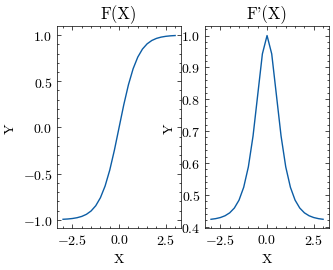

In [8]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)


Tanh().plot(-3, 3)

## 优化器（Optimizer）

我们的优化算法将采用梯度下降，从而确定下一次迭代中该如何更新参数。

$ X_{n+1} = X_n - lr * \frac{\partial}{\partial X} f(X_n)$.

让我们创建一个类，用梯度下降公式来更新权重矩阵和偏置向量。

In [9]:
class GradientDescentOptimizier:
    def __init__(self, learning_rate):
        self.learning_rate = learning_rate

    def backward(self, weights, weights_gradient, bias, output_gradient):
        weights -= self.learning_rate * weights_gradient
        bias -= self.learning_rate * output_gradient

        return weights, bias

## 绘图函数

本 Notebook 会在训练阶段创建大量神经网络的可视化图表。

`create_scatter_and_3d_plot()` 创建一个两列图表：左侧是均方误差（Mean Squared Error）曲线，右侧是 3D 图。

`create_3d_and_3d_plot()` 创建一个包含两张 3D 图的两列图表。

`plot_3d_predictions()` 绘制神经网络当前的预测值以及神经网络的期望输出。

`plot_layer_loss_landscape()` 通过观察权重稍微偏移时总均方误差如何变化，来绘制某一层当前权重与最优权重的接近程度。

In [10]:
import copy


def create_scatter_and_3d_plot():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Neural Network Predictions")

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Error", fontweight="normal")
    ax[0].set_title("Mean Squared Error")

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Function Approximation")
    ax[2].view_init(20, -35)
    ax[2].set_zlim(-1, 1)
    ax[2].axis("equal")

    camera = Camera(fig)
    return ax[0], ax[2], camera


def create_3d_and_3d_plot():
    fig, ax = plt.subplots(
        1, 2, figsize=(16 / 9.0 * 4, 4 * 1), subplot_kw={"projection": "3d"}
    )
    fig.suptitle("Neural Network Loss Landscape")

    ax[0].set_xlabel("W3_1")
    ax[0].set_ylabel("W3_2")
    ax[0].set_zlabel("MSE")
    ax[0].set_title("Mean Squared Error")
    ax[0].view_init(20, -35)
    ax[0].set_zlim(-1, 1)
    ax[0].axis("equal")

    ax[1].set_xlabel("X")
    ax[1].set_ylabel("Y")
    ax[1].set_zlabel("Z")
    ax[1].set_title("Function Approximation")
    ax[1].view_init(20, -35)
    ax[1].set_zlim(-1, 1)
    ax[1].axis("equal")

    camera = Camera(fig)
    return ax[0], ax[1], camera


def plot_3d_predictions(ax, X, Y, Z, predictions, dims):
    # 绘制神经网络的函数逼近图
    # 真实值
    ground_truth_legend = ax.plot_surface(
        X, Y, Z, color="red", alpha=0.5, label="Ground Truth"
    )

    # 神经网络的预测值
    predictions_legend = ax.scatter(
        X,
        Y,
        predictions.reshape((dims, dims)),
        color="blue",
        alpha=0.2,
        label="Prediction",
    )
    ax.plot_surface(
        X,
        Y,
        predictions.reshape((dims, dims)),
        color="blue",
        alpha=0.3,
    )
    ax.legend(
        (ground_truth_legend, predictions_legend),
        ("Ground Truth", "Predictions"),
        loc="upper left",
    )


def plot_layer_loss_landscape(
    ax0,
    network,
    target_layer_idx,
    features,
    labels,
    w1_min,
    w1_max,
    w2_min,
    w2_max,
    loss_dims,
):
    # 当前目标层的权重
    target_layer_idx = target_layer_idx % len(network)

    w1 = network[target_layer_idx].weights[0][0]
    w2 = network[target_layer_idx].weights[0][1]
    curr_error = 0
    for x, y in zip(features, labels):
        output = x
        for layer in network:
            output = layer.forward(output)

        curr_error += mse(y, output)
    curr_error /= labels.size
    ax0.scatter([w1], [w2], [curr_error], color="red", alpha=0.4)

    target_layer = copy.deepcopy(network[target_layer_idx])
    w1_range = np.linspace(w1_min, w1_max, loss_dims)
    w2_range = np.linspace(w2_min, w2_max, loss_dims)
    w1_range, w2_range = np.meshgrid(w1_range, w2_range)
    w_range = np.stack((w1_range.flatten(), w2_range.flatten()), axis=1)

    error_range = np.array([])

    for target_layer_weight in w_range:
        target_layer_weight = target_layer_weight.reshape(1, 2)
        target_layer.weights[0, :2] = target_layer_weight[0, :2]

        error = 0
        for x, y in zip(features, labels):
            output = x
            for layer_idx, layer in enumerate(network):
                if layer_idx == target_layer_idx:
                    output = target_layer.forward(output)
                else:
                    output = layer.forward(output)

            error += mse(y, output)
        error /= labels.size
        error_range = np.append(error_range, error)

    ax0.plot_surface(
        w1_range,
        w2_range,
        error_range.reshape(loss_dims, loss_dims),
        color="blue",
        alpha=0.1,
    )


def plot_mse_and_predictions(
    ax0, ax1, idx, visible_mse, mse_idx, errors, X, Y, Z, predictions, dims
):
    ax0.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )

    plot_3d_predictions(ax1, X, Y, Z, predictions, dims)


def plot_loss_landscape_and_predictions(
    ax0,
    ax1,
    network,
    target_layer_idx,
    features,
    labels,
    X,
    Y,
    Z,
    predictions,
    preds_dims,
    w1_min=-5,
    w1_max=5,
    w2_min=-5,
    w2_max=5,
    loss_dims=20,
):
    plot_3d_predictions(ax1, X, Y, Z, predictions, preds_dims)
    plot_layer_loss_landscape(
        ax0,
        network,
        target_layer_idx,
        features,
        labels,
        w1_min,
        w1_max,
        w2_min,
        w2_max,
        loss_dims,
    )


def show_epoch(epoch):
    return (
        epoch < 25
        or (epoch < 25 and epoch % 2 == 0)
        or (epoch <= 100 and epoch % 10 == 0)
        or (epoch <= 500 and epoch % 25 == 0)
        or (epoch <= 1000 and epoch % 50 == 0)
        or epoch % 250 == 0
    )

## 训练模型

让我们把所有内容整合起来训练神经网络。在每个训练轮（Epoch）中，我们将执行以下步骤：

1. 把训练数据传入模型，得到模型的预测结果
2. 根据模型的预测值和期望值计算损失
3. 利用损失运行优化器，更新权重和偏置
4. 调用可视化函数，将训练过程可视化

In [11]:
def fit(
    network,
    features,
    labels,
    X,
    Y,
    Z,
    preds_dims,
    epochs,
    optimizer,
    mse_plot_filename,
    loss_landscape_plot_filename,
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    mse_ax, predictions_ax1, camera1 = create_scatter_and_3d_plot()
    loss_landscape_ax, predictions_ax2, camera2 = create_3d_and_3d_plot()

    network_len = len(network)

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # 前向传播
            output = x
            for layer in network:
                output = layer.forward(output)

            predictions = np.append(predictions, output)

            # 记录误差
            # 无需转换为 numpy cpu，因为两者都是设备上的张量
            error += mse(y, output)

            # 反向传播
            grad = mse_prime(y, output)
            for layer in reversed(network):
                grad = layer.backward(grad, optimizer)

        error /= len(X)

        if show_epoch(idx):
            print(f"epoch: {idx}, MSE: {error}")

            # 绘制均方误差图
            errors[idx] = error
            visible_mse = errors != -1
            plot_mse_and_predictions(
                mse_ax,
                predictions_ax1,
                idx,
                visible_mse,
                mse_idx,
                errors,
                X,
                Y,
                Z,
                predictions,
                preds_dims,
            )

            # 绘制倒数第二层的损失地形图
            # 因为只有 2 个神经元，所以可以画 3D 图
            plot_loss_landscape_and_predictions(
                loss_landscape_ax,
                predictions_ax2,
                network,
                -2,
                features,
                labels,
                X,
                Y,
                Z,
                predictions,
                preds_dims,
            )

            camera1.snap()
            camera2.snap()

    animation1 = camera1.animate()
    animation1.save(mse_plot_filename, writer="pillow")

    animation2 = camera2.animate()
    animation2.save(loss_landscape_plot_filename, writer="pillow")
    plt.show()

模型可以用下面的图片来可视化：

<img src="plot/architecture/nn-1.png" alt="Fully Connected Neural Network" width="400" />

我们的模型由 3 层组成，每一层之后都接有 Tanh() 激活函数。

第 1 层：
- 输入维度：2
- 输出维度：12

第 2 层：
- 输入维度：12
- 输出维度：2

第 3 层：
- 输入维度：2
- 输出维度：1

In [12]:
model = [Dense(2, 12), Tanh(), Dense(12, 2), Tanh(), Dense(2, 1), Tanh()]

把模型和优化器传给训练方法，来训练我们的模型

epoch: 0, MSE: 3.0033681391919607
epoch: 1, MSE: 2.861607692334731
epoch: 2, MSE: 2.825853287737221
epoch: 3, MSE: 2.817140865761648
epoch: 4, MSE: 2.814117393067351
epoch: 5, MSE: 2.8099737108937255
epoch: 6, MSE: 2.8023452137616185
epoch: 7, MSE: 2.7902417103220167
epoch: 8, MSE: 2.773063690822775
epoch: 9, MSE: 2.7502645093729323
epoch: 10, MSE: 2.721249705555072
epoch: 11, MSE: 2.685389899197139
epoch: 12, MSE: 2.642101512218608
epoch: 13, MSE: 2.590967280467696
epoch: 14, MSE: 2.531869391821693
epoch: 15, MSE: 2.4651083530357476
epoch: 16, MSE: 2.3914851384273637
epoch: 17, MSE: 2.3123291935128214
epoch: 18, MSE: 2.229456375261003
epoch: 19, MSE: 2.1450438173269872
epoch: 20, MSE: 2.061423945351905
epoch: 21, MSE: 1.9808288922004156
epoch: 22, MSE: 1.9051432156154482
epoch: 23, MSE: 1.8357262341875262
epoch: 24, MSE: 1.773340422003911
epoch: 25, MSE: 1.7181844787747815
epoch: 30, MSE: 1.5333665989875438
epoch: 40, MSE: 1.3570304555393908
epoch: 50, MSE: 1.2049292538302114
epoch: 6

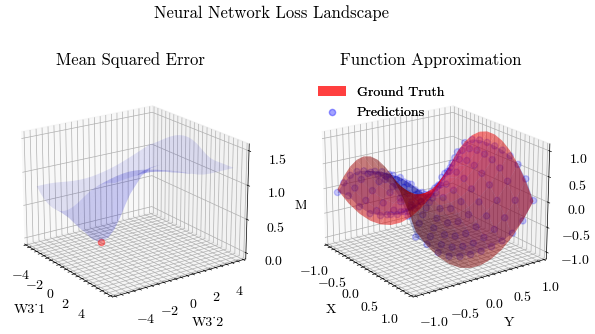

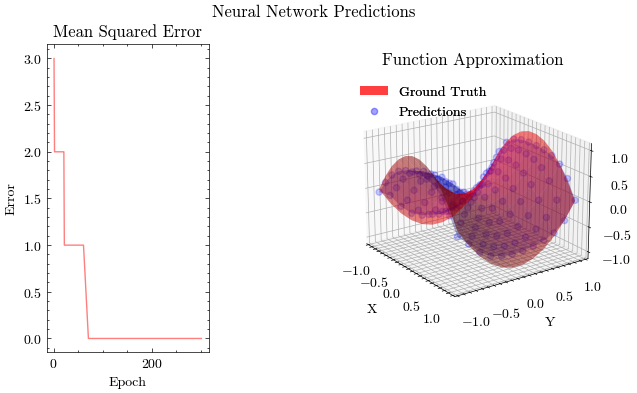

In [13]:
epochs = 301
learning_rate = 0.005
optimizer = GradientDescentOptimizier(learning_rate)

mse_plot_filename = "neural_network.gif"
loss_landscape_plot_filename = "neural_network_loss_landscape.gif"
fit(
    model,
    features,
    labels,
    X,
    Y,
    Z,
    dims,
    epochs,
    optimizer,
    mse_plot_filename,
    loss_landscape_plot_filename,
)

## 输出 GIF

在这个可视化中，我们可以看到预测结果与真实值（Ground Truth）吻合。神经网络成功找到了拟合这个函数的最优参数。现在想一想它的应用：给定关于人们购物习惯的输入数据，我们就能预测可以推荐给他们的内容。我们可以推荐一条社交媒体动态给他们看，也可以推荐他们接下来可以看的节目。我们可以把数据传给神经网络，它会从输入数据中发掘规律并找出其中的模式。

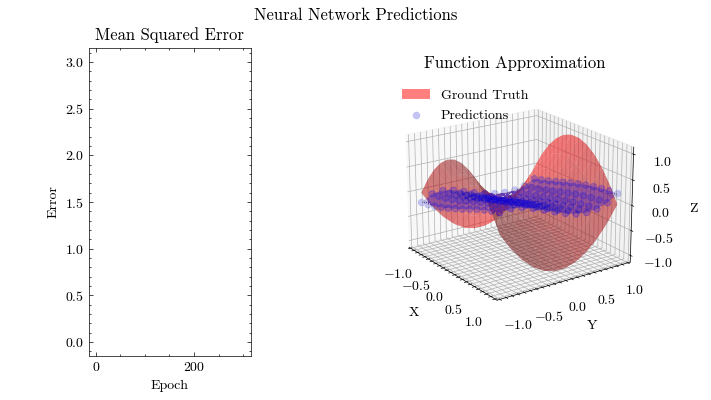

In [14]:
Image(filename=mse_plot_filename)

下面的可视化表明反向传播为神经网络找到了最优权重。在左侧图中，红点表示神经网络最后一层权重矩阵的当前值。z 轴表示均方误差损失。如果权重不在当前取值上，损失就不会处在极小值处，这说明反向传播确实会把权重更新到最优（局部极值）值，并使网络收敛。

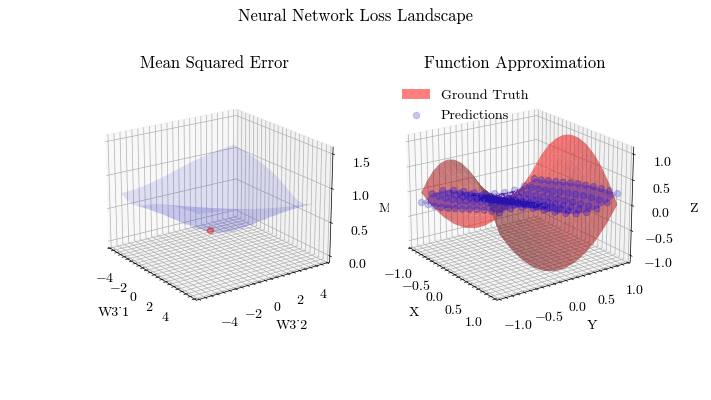

In [15]:
Image(filename=loss_landscape_plot_filename)

## PyTorch 实现

机器学习（Machine Learning）库（例如 PyTorch）提供了各种工具，可以在各类经过优化的硬件上轻松训练和测试神经网络。现在我们用 PyTorch 实现同一个网络。

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

## PyTorch 的 nn.Module

我们通过创建 PyTorch 类 `nn.Module` 的一个子类来表示神经网络，这个子类定义了网络中的所有层以及数据在网络中的流动方式。`forward()` 方法就是我们神经网络的前向传播。注意，我们不需要为反向传播过程指定任何内容。PyTorch 借助其自动微分（Auto-differentiation）支持替我们完成了这件事。我们只需要导入一个优化器类，比如 PyTorch 提供的梯度下降类，然后传入模型的参数即可。这就是使用机器学习库的魅力所在。

In [17]:
class TorchNet(nn.Module):
    def __init__(self):
        super(TorchNet, self).__init__()

        # 定义各层
        self.fc1 = nn.Linear(2, 14)
        self.fc2 = nn.Linear(14, 2)
        self.fc3 = nn.Linear(2, 1)

    def forward(self, x):
        # 把上一层的结果传给下一层
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        return F.tanh(self.fc3(x))

## PyTorch 训练

与我们自己的实现类似，让我们用模型来定义训练过程。在每个训练轮中，我们将执行以下步骤：

1. 把训练数据传入模型，得到模型的预测结果
2. 根据模型的预测值和期望值计算损失
3. 利用损失运行优化器，更新权重和偏置
4. 调用可视化函数，将训练过程可视化

In [18]:
def torch_fit(
    model, features, labels, X, Y, Z, dims, epochs, optimizer, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    mse_ax, predictions_ax1, camera1 = create_scatter_and_3d_plot()

    loss_fn = nn.MSELoss()

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # 前向传播
            output = model(x)

            output_np = output.detach().cpu().numpy()
            predictions = np.append(predictions, output_np)

            # 记录误差
            loss = loss_fn(output, y)

            error += loss.detach().cpu().numpy()

            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        error /= len(X)

        if show_epoch(idx):
            print(f"epoch: {idx}, MSE: {error}")

            # 绘制均方误差图
            errors[idx] = error
            visible_mse = errors != -1

            plot_mse_and_predictions(
                mse_ax,
                predictions_ax1,
                idx,
                visible_mse,
                mse_idx,
                errors,
                X,
                Y,
                Z,
                predictions,
                dims,
            )

            camera1.snap()

    animation1 = camera1.animate()
    animation1.save(output_filename, writer="pillow")
    plt.show()

调用训练方法，传入模型、训练数据和优化器。

epoch: 0, MSE: 2.984565019607544
epoch: 1, MSE: 2.7075679302215576
epoch: 2, MSE: 2.6843478679656982
epoch: 3, MSE: 2.6776466369628906
epoch: 4, MSE: 2.681764841079712
epoch: 5, MSE: 2.690561294555664
epoch: 6, MSE: 2.700050115585327
epoch: 7, MSE: 2.7078511714935303
epoch: 8, MSE: 2.7127301692962646
epoch: 9, MSE: 2.7142038345336914
epoch: 10, MSE: 2.712219476699829
epoch: 11, MSE: 2.7069084644317627
epoch: 12, MSE: 2.698435068130493
epoch: 13, MSE: 2.686903715133667
epoch: 14, MSE: 2.672306776046753
epoch: 15, MSE: 2.654496908187866
epoch: 16, MSE: 2.6331663131713867
epoch: 17, MSE: 2.607834577560425
epoch: 18, MSE: 2.5778284072875977
epoch: 19, MSE: 2.5422799587249756
epoch: 20, MSE: 2.500131607055664
epoch: 21, MSE: 2.4501821994781494
epoch: 22, MSE: 2.3912034034729004
epoch: 23, MSE: 2.322108507156372
epoch: 24, MSE: 2.242227554321289
epoch: 25, MSE: 2.151536703109741
epoch: 30, MSE: 1.5780051946640015
epoch: 40, MSE: 0.4502718448638916
epoch: 50, MSE: 0.15558312833309174
epoch: 6

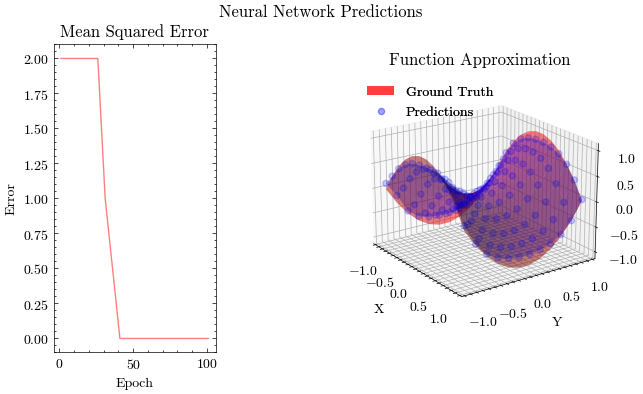

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch_model = TorchNet().to(device)

# PyTorch 的输入和输出必须是张量
features_tensor = torch.tensor(features, device=device, dtype=torch.float32).squeeze(-1)
labels_tensor = torch.tensor(labels, device=device, dtype=torch.float32).squeeze(-1)

epochs = 101
learning_rate = 0.005
optimizer = torch.optim.SGD(torch_model.parameters(), lr=learning_rate, momentum=0.0)

output_filename_pytorch = "neural_network_pytorch.gif"
torch_fit(
    torch_model,
    features_tensor,
    labels_tensor,
    X,
    Y,
    Z,
    dims,
    epochs,
    optimizer,
    output_filename_pytorch,
)

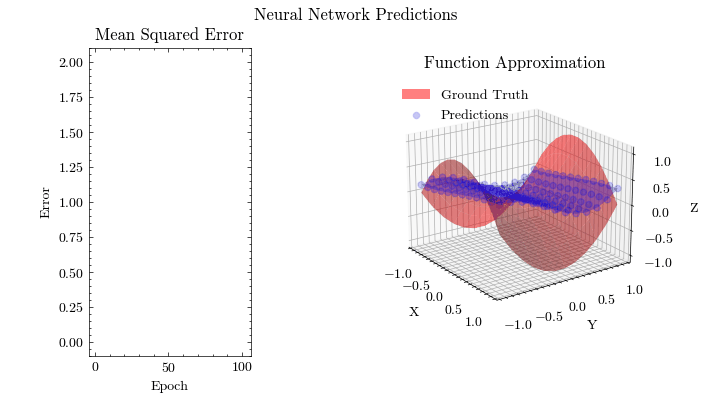

In [20]:
Image(filename=output_filename_pytorch)